In [1]:
!pip install librosa soundfile tensorflow scikit-learn matplotlib seaborn -q

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_8cacd5277b27b503678db9ccdc826864'
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio -p /content/
!unzip -q /content/ravdess-emotional-speech-audio.zip -d /content/ravdess_data


Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:03<00:00, 139MB/s]



In [3]:
import os
import librosa
import numpy as np
import pandas as pd

# Функция для извлечения эмоции из имени файла
def extract_emotion_from_filename(filename):
    """Извлекает эмоцию из имени файла RAVDESS"""
    # Формат: 03-01-01-01-01-01-01.wav
    # Индекс эмоции на позиции 3 (после 2-х дефисов)
    parts = filename.split('-')
    if len(parts) >= 3:
        emotion_code = int(parts[2])
        # Маппинг кодов эмоций
        emotion_map = {
            1: 'neutral',
            2: 'calm',
            3: 'happy',
            4: 'sad',
            5: 'angry',
            6: 'fearful',
            7: 'disgust',
            8: 'surprised'
        }
        return emotion_map.get(emotion_code, 'unknown')
    return 'unknown'

# Функция для загрузки аудио и извлечения признаков
def extract_audio_features(file_path, duration=3, sr=22050):
    """Извлекает признаки из аудиофайла"""
    try:
        # Загружаем аудио
        y, sr = librosa.load(file_path, sr=sr, duration=duration)

        # 1. MFCC (13 коэффициентов)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc.T, axis=0)
        mfcc_std = np.std(mfcc.T, axis=0)

        # 2. Спектральные признаки
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_centroid_mean = np.mean(spectral_centroid)

        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        spectral_bandwidth_mean = np.mean(spectral_bandwidth)

        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_rolloff_mean = np.mean(spectral_rolloff)

        # 3. Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y=y)
        zcr_mean = np.mean(zcr)

        # 4. RMS Energy
        rms = librosa.feature.rms(y=y)
        rms_mean = np.mean(rms)

        # 5. Pitch (высота тона)
        pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
        pitch_mean = np.mean(pitches[pitches > 0]) if np.any(pitches > 0) else 0

        # 6. Tempo
        try:
            tempo_array, _ = librosa.beat.beat_track(y=y, sr=sr)
            tempo = float(tempo_array[0] if isinstance(tempo_array, np.ndarray) else tempo_array)
        except:
            tempo = 0

        # 7. Mel-spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_mean = np.mean(mel)
        mel_std = np.std(mel)

        # Объединяем все признаки
        features = np.concatenate([
            mfcc_mean,              # 13
            mfcc_std,               # 13
            [spectral_centroid_mean],   # 1
            [spectral_bandwidth_mean],  # 1
            [spectral_rolloff_mean],    # 1
            [zcr_mean],             # 1
            [rms_mean],             # 1
            [pitch_mean],           # 1
            [tempo],                # 1
            [mel_mean],             # 1
            [mel_std]               # 1
        ])

        return features

    except Exception as e:
        print(f"Ошибка с файлом {file_path}: {e}")
        return None

# Загружаем датасет
def load_ravdess_dataset(data_path, max_files_per_emotion=None):
    """Загружает датасет RAVDESS"""
    X = []
    y = []

    print("Загрузка датасета RAVDESS...")

    # Проходим по всем папкам
    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith('.wav'):
                # Извлекаем эмоцию
                emotion = extract_emotion_from_filename(file)

                if emotion != 'unknown':
                    file_path = os.path.join(root, file)
                    features = extract_audio_features(file_path)

                    if features is not None:
                        X.append(features)
                        y.append(emotion)

    X = np.array(X)
    y = np.array(y)

    print(f"Загружено {len(X)} файлов")
    print(f"Размер признаков: {X[0].shape if len(X) > 0 else 0}")
    print(f"Эмоции: {np.unique(y)}")

    return X, y

# Загружаем датасет
X, y = load_ravdess_dataset('/content/ravdess_data')

Загрузка датасета RAVDESS...
Загружено 2880 файлов
Размер признаков: (35,)
Эмоции: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


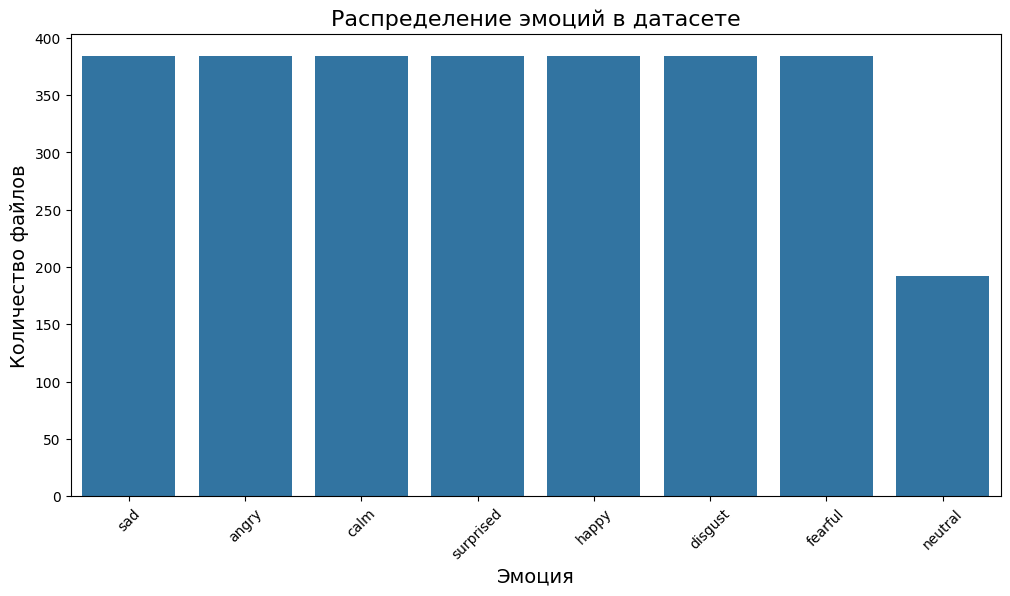

Распределение эмоций:
  sad: 384 файлов
  angry: 384 файлов
  calm: 384 файлов
  surprised: 384 файлов
  happy: 384 файлов
  disgust: 384 файлов
  fearful: 384 файлов
  neutral: 192 файлов


In [4]:
plt.figure(figsize=(12, 6))
emotion_counts = pd.Series(y).value_counts()
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)
plt.title('Распределение эмоций в датасете', fontsize=16)
plt.xlabel('Эмоция', fontsize=14)
plt.ylabel('Количество файлов', fontsize=14)
plt.xticks(rotation=45)
plt.show()

print("Распределение эмоций:")
for emotion, count in emotion_counts.items():
    print(f"  {emotion}: {count} файлов")

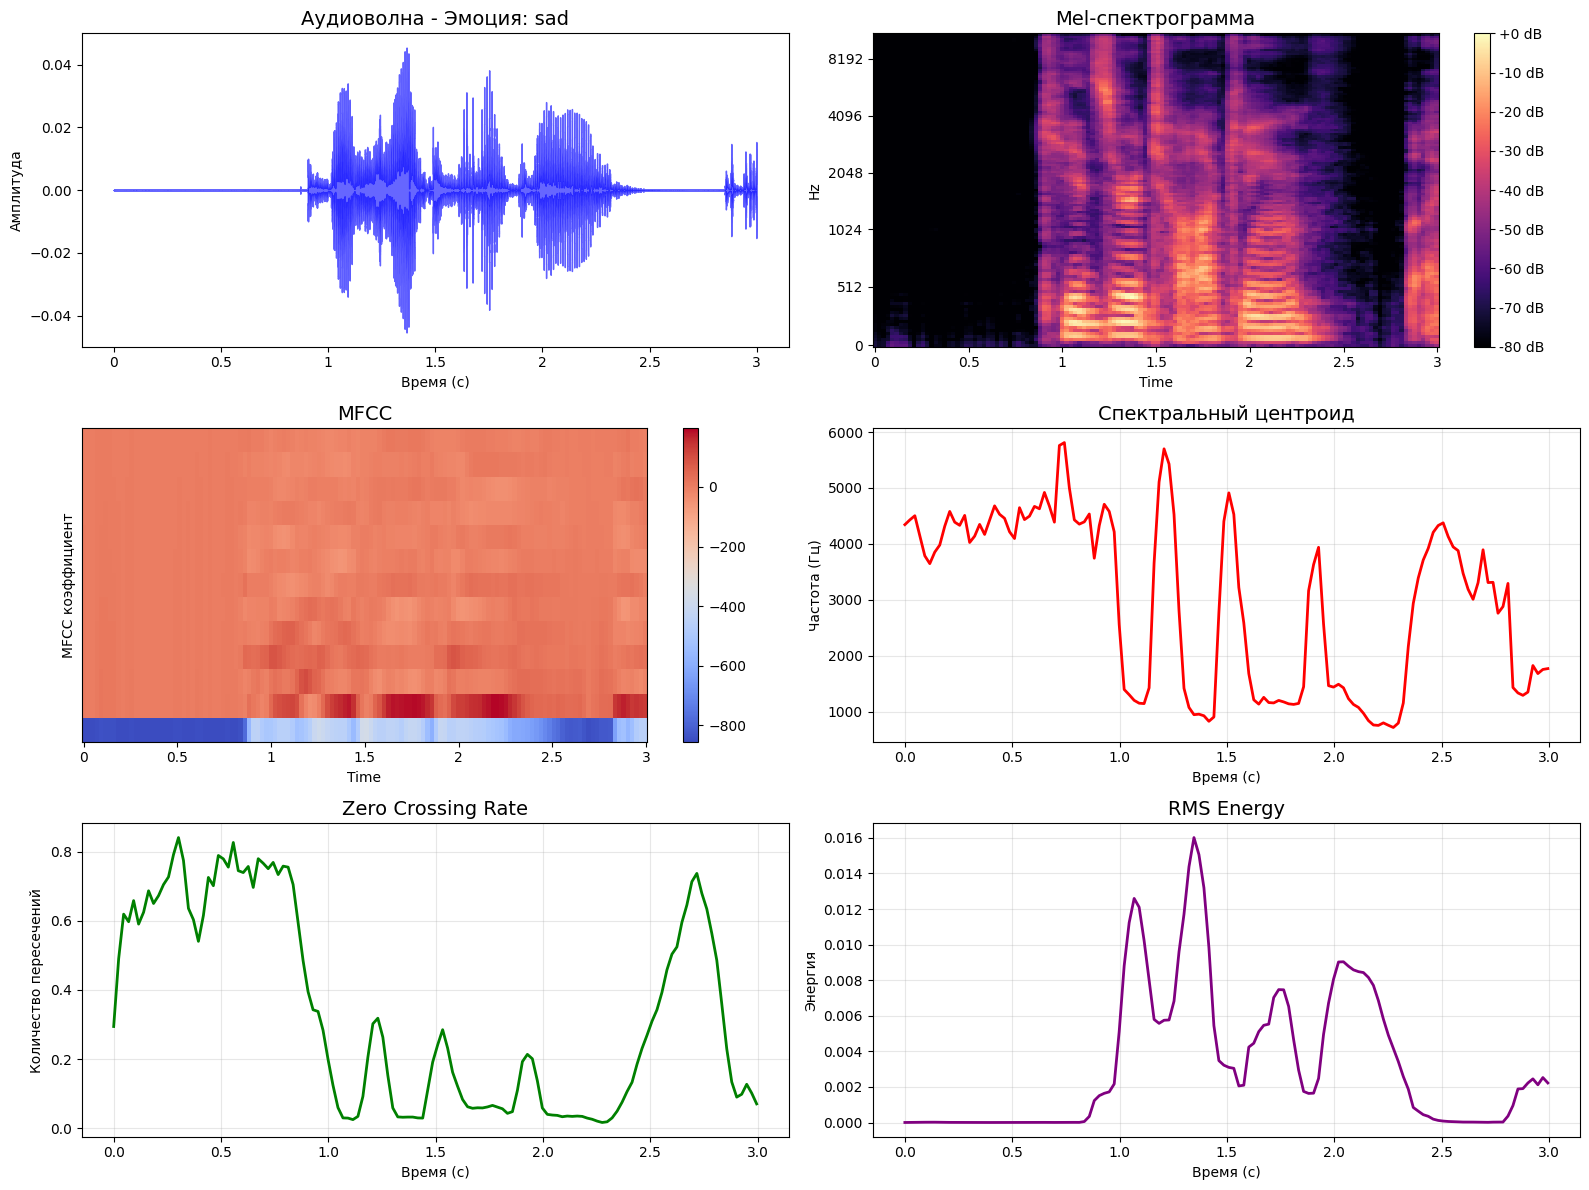

Эмоция файла: sad


In [5]:
def visualize_audio_and_features(file_path):
    """Визуализирует аудио и его признаки"""
    # Загружаем аудио
    y, sr = librosa.load(file_path, sr=22050, duration=3)

    # Извлекаем признаки
    emotion = extract_emotion_from_filename(os.path.basename(file_path))

    # Создаём графики
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    axes = axes.flatten()

    # 1. Волна
    librosa.display.waveshow(y, sr=sr, ax=axes[0], alpha=0.6, color='blue')
    axes[0].set_title(f'Аудиоволна - Эмоция: {emotion}', fontsize=14)
    axes[0].set_xlabel('Время (с)')
    axes[0].set_ylabel('Амплитуда')

    # 2. Спектрограмма
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
    axes[1].set_title('Mel-спектрограмма', fontsize=14)
    plt.colorbar(img, ax=axes[1], format='%+2.0f dB')

    # 3. MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[2])
    axes[2].set_title('MFCC', fontsize=14)
    axes[2].set_ylabel('MFCC коэффициент')
    plt.colorbar(img, ax=axes[2])

    # 4. Спектральный центроид
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    frames = range(len(spectral_centroid))
    t = librosa.frames_to_time(frames, sr=sr)
    axes[3].plot(t, spectral_centroid, color='red', linewidth=2)
    axes[3].set_title('Спектральный центроид', fontsize=14)
    axes[3].set_xlabel('Время (с)')
    axes[3].set_ylabel('Частота (Гц)')
    axes[3].grid(True, alpha=0.3)

    # 5. Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    axes[4].plot(t, zcr, color='green', linewidth=2)
    axes[4].set_title('Zero Crossing Rate', fontsize=14)
    axes[4].set_xlabel('Время (с)')
    axes[4].set_ylabel('Количество пересечений')
    axes[4].grid(True, alpha=0.3)

    # 6. RMS Energy
    rms = librosa.feature.rms(y=y)[0]
    axes[5].plot(t, rms, color='purple', linewidth=2)
    axes[5].set_title('RMS Energy', fontsize=14)
    axes[5].set_xlabel('Время (с)')
    axes[5].set_ylabel('Энергия')
    axes[5].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return emotion

# Визуализируем случайный файл
files = []
for root, dirs, files_list in os.walk('/content/ravdess_data'):
    for file in files_list:
        if file.endswith('.wav'):
            files.append(os.path.join(root, file))
            break
    if files:
        break

if files:
    emotion = visualize_audio_and_features(files[0])
    print(f"Эмоция файла: {emotion}")

In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Кодируем эмоции
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Кодирование эмоций:")
for idx, emotion in enumerate(le.classes_):
    print(f"  {emotion} -> {idx}")

# Масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTrain: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")
print(f"Количество классов: {len(np.unique(y_encoded))}")

Кодирование эмоций:
  angry -> 0
  calm -> 1
  disgust -> 2
  fearful -> 3
  happy -> 4
  neutral -> 5
  sad -> 6
  surprised -> 7

Train: 2304 samples
Test: 576 samples
Количество классов: 8



XGBoost
Точность: 92.71%

Отчёт по каждому классу:
              precision    recall  f1-score   support

       angry       0.94      0.89      0.92        76
        calm       0.97      0.95      0.96        77
     disgust       0.95      0.90      0.92        77
     fearful       0.92      0.95      0.94        77
       happy       0.90      0.95      0.92        77
     neutral       0.90      1.00      0.95        38
         sad       0.87      0.84      0.86        77
   surprised       0.95      0.97      0.96        77

    accuracy                           0.93       576
   macro avg       0.93      0.93      0.93       576
weighted avg       0.93      0.93      0.93       576



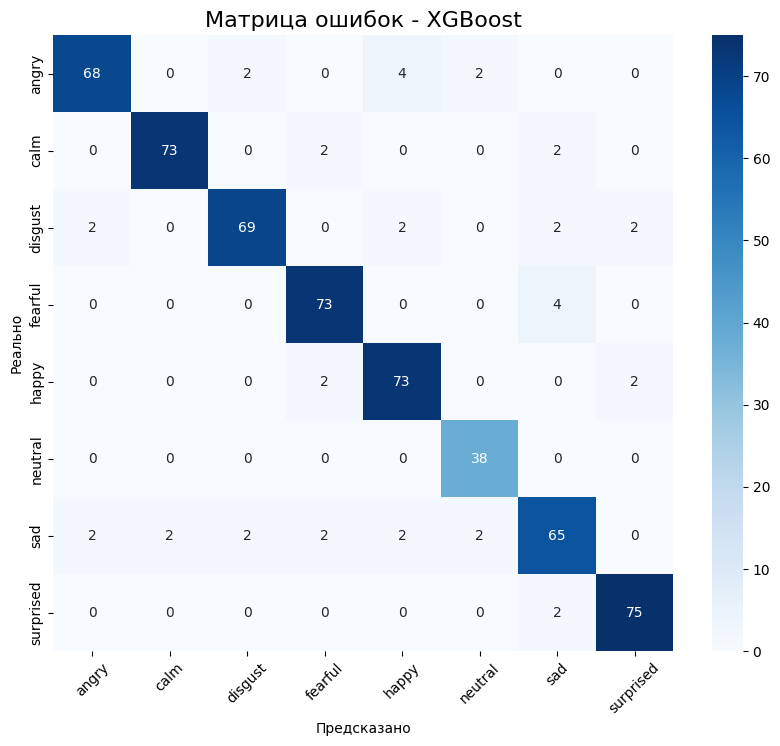


Random Forest
Точность: 90.80%

Отчёт по каждому классу:
              precision    recall  f1-score   support

       angry       0.97      0.87      0.92        76
        calm       0.84      0.92      0.88        77
     disgust       0.92      0.90      0.91        77
     fearful       0.97      0.90      0.93        77
       happy       0.90      0.96      0.93        77
     neutral       0.95      0.92      0.93        38
         sad       0.89      0.81      0.84        77
   surprised       0.88      1.00      0.93        77

    accuracy                           0.91       576
   macro avg       0.91      0.91      0.91       576
weighted avg       0.91      0.91      0.91       576



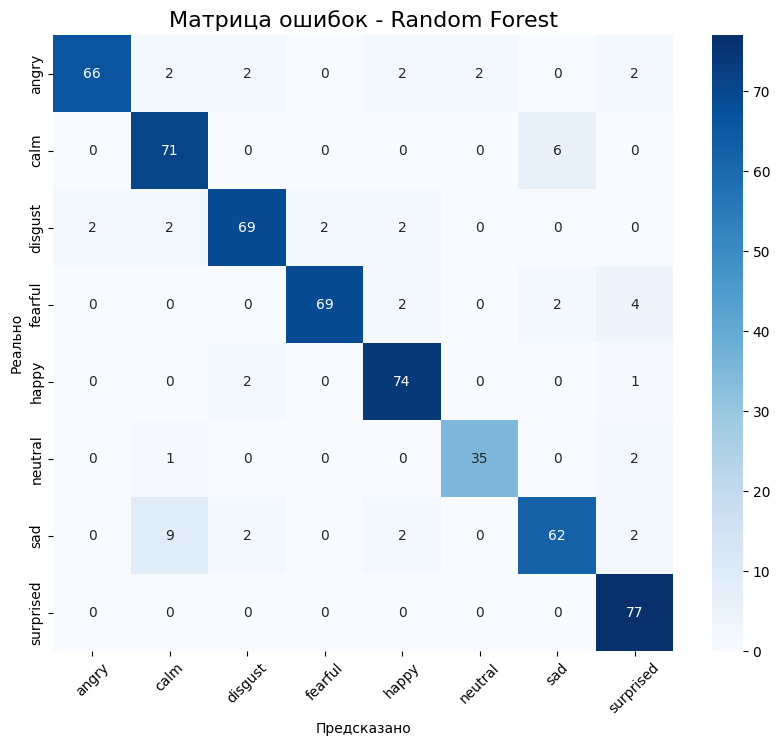


Gradient Boosting
Точность: 92.01%

Отчёт по каждому классу:
              precision    recall  f1-score   support

       angry       0.94      0.89      0.92        76
        calm       0.97      0.97      0.97        77
     disgust       0.92      0.90      0.91        77
     fearful       0.90      0.92      0.91        77
       happy       0.87      0.90      0.88        77
     neutral       0.95      1.00      0.97        38
         sad       0.86      0.82      0.84        77
   surprised       0.95      1.00      0.97        77

    accuracy                           0.92       576
   macro avg       0.92      0.93      0.92       576
weighted avg       0.92      0.92      0.92       576



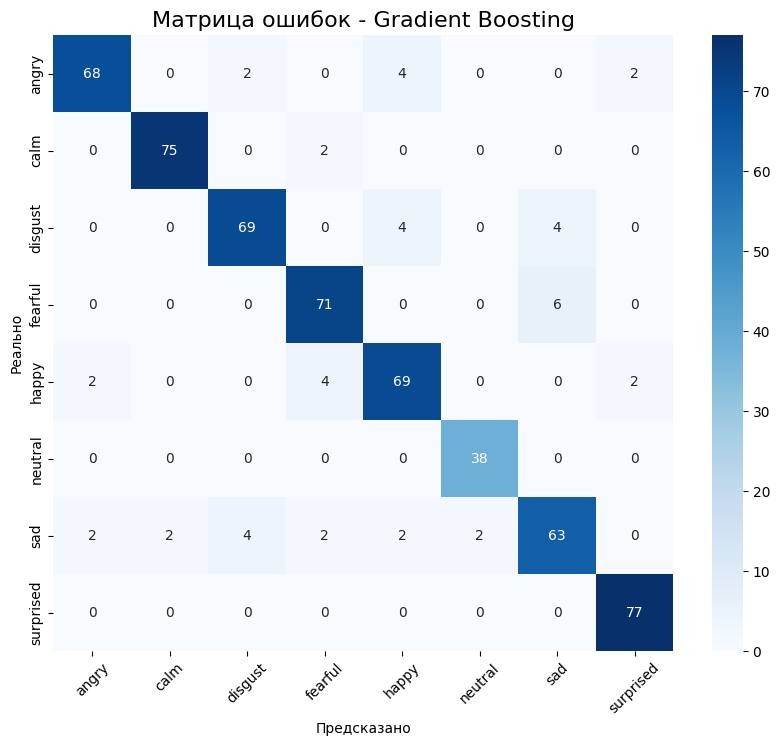


SVM
Точность: 78.30%

Отчёт по каждому классу:
              precision    recall  f1-score   support

       angry       0.88      0.78      0.83        76
        calm       0.71      0.90      0.79        77
     disgust       0.73      0.79      0.76        77
     fearful       0.84      0.84      0.84        77
       happy       0.82      0.78      0.80        77
     neutral       0.77      0.61      0.68        38
         sad       0.70      0.73      0.71        77
   surprised       0.84      0.75      0.79        77

    accuracy                           0.78       576
   macro avg       0.79      0.77      0.78       576
weighted avg       0.79      0.78      0.78       576



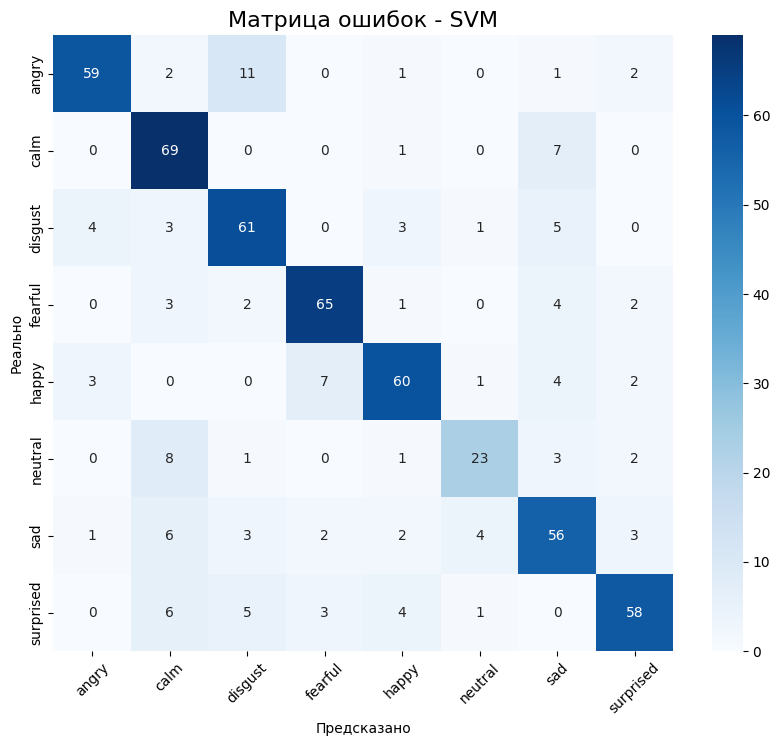

In [7]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Функция для оценки модели
def evaluate_model(model, model_name="Model"):
    """Оценивает модель"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print(f"Точность: {accuracy:.2%}")
    print(f"\nОтчёт по каждому классу:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Матрица ошибок - {model_name}', fontsize=16)
    plt.xlabel('Предсказано')
    plt.ylabel('Реально')
    plt.xticks(rotation=45)
    plt.show()

    return model

# 1. XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_model = evaluate_model(xgb, "XGBoost")

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model = evaluate_model(rf, "Random Forest")

# 3. Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model = evaluate_model(gb, "Gradient Boosting")

# 4. SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model = evaluate_model(svm, "SVM")

XGBoost: 92.71%
Random Forest: 90.80%
Gradient Boosting: 92.01%
SVM: 78.30%


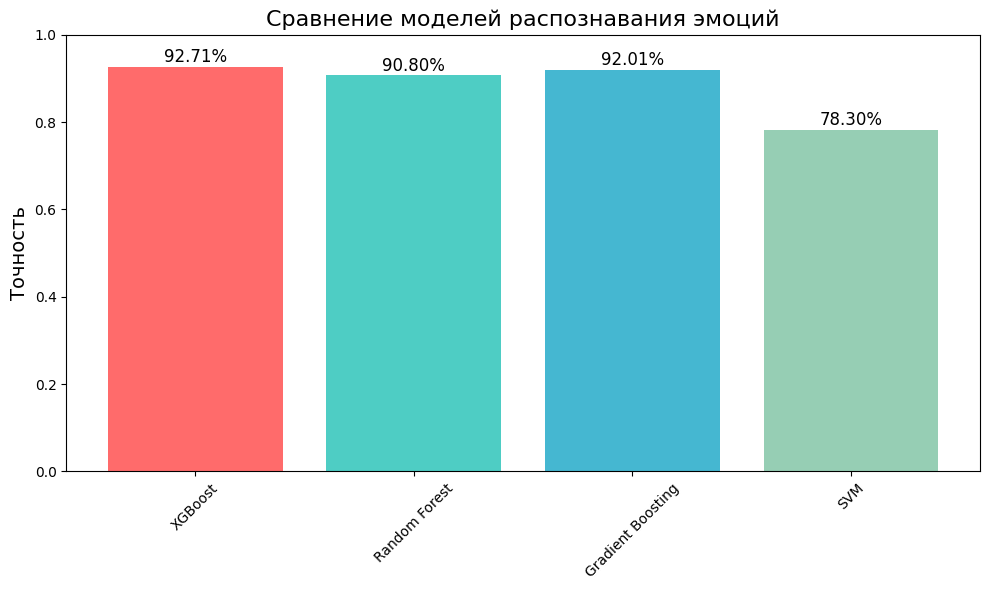

In [8]:
# Сравниваем все модели
models = {
    'XGBoost': xgb_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'SVM': svm_model
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name}: {accuracy:.2%}")

# Визуализация
plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Сравнение моделей распознавания эмоций', fontsize=16)
plt.ylabel('Точность', fontsize=14)
plt.ylim(0, 1)
plt.xticks(rotation=45)

for bar, (name, acc) in zip(bars, results.items()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [9]:
def predict_emotion_from_audio(file_path, model, scaler, label_encoder):
    """Предсказывает эмоцию из аудиофайла"""
    try:
        # Извлекаем признаки
        features = extract_audio_features(file_path)

        if features is not None:
            # Масштабируем
            features_scaled = scaler.transform([features])

            # Предсказываем
            pred = model.predict(features_scaled)
            emotion = label_encoder.inverse_transform(pred)[0]

            # Вероятности
            if hasattr(model, 'predict_proba'):
                probabilities = model.predict_proba(features_scaled)[0]
                confidence = np.max(probabilities)
                return emotion, confidence
            else:
                return emotion, None
        else:
            return None, None

    except Exception as e:
        print(f"Ошибка: {e}")
        return None, None

# Пример использования
if files:
    emotion, confidence = predict_emotion_from_audio(files[0], xgb_model, scaler, le)
    if emotion:
        print(f"Предсказанная эмоция: {emotion}")
        print(f"Уверенность: {confidence:.2%}" if confidence else "Уверенность: N/A")

Предсказанная эмоция: sad
Уверенность: 98.50%


Загрузите аудиофайл для распознавания эмоции:


Saving Jul 24, 22.22​.aac to Jul 24, 22.22​ (2).aac

Анализ файла: Jul 24, 22.22​ (2).aac
🔄 Конвертация AAC в WAV...
✅ Конвертация завершена!
✅ Распознанная эмоция: FEARFUL


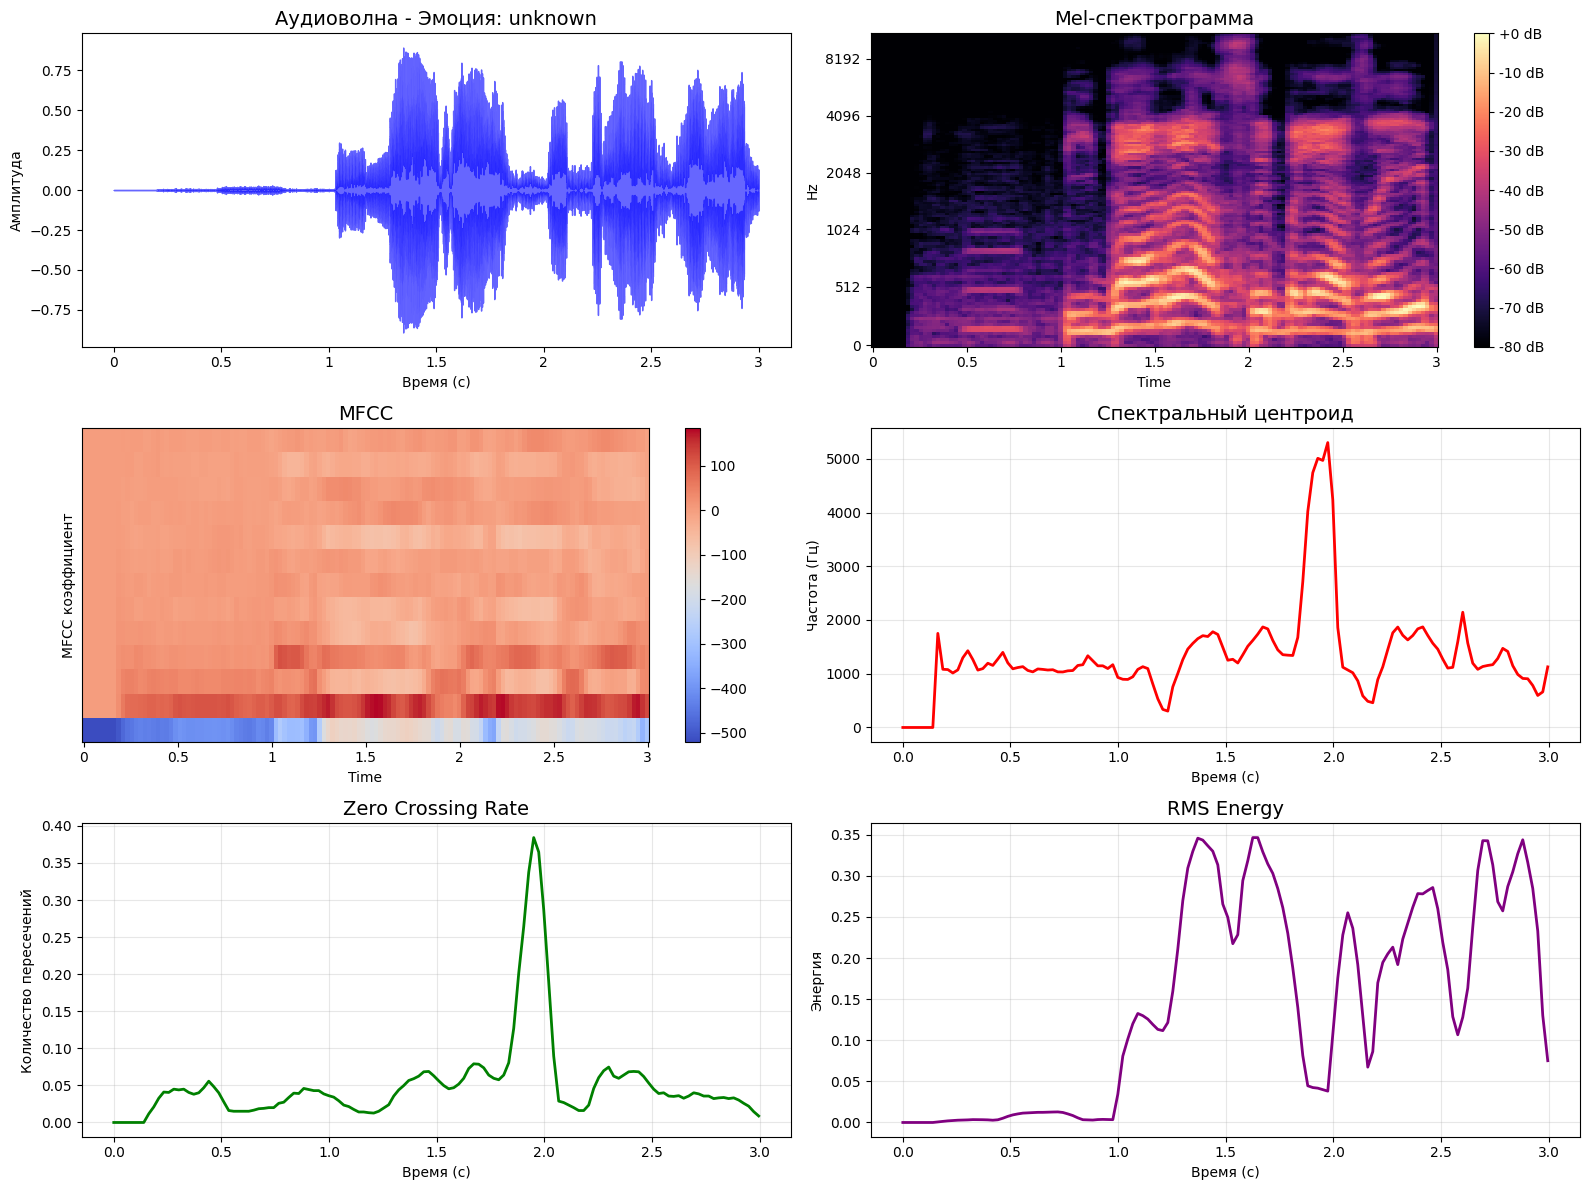

In [13]:
from google.colab import files
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Загружаем аудиофайл
print("Загрузите аудиофайл для распознавания эмоции:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nАнализ файла: {filename}")

    # Конвертируем AAC в WAV если нужно
    if filename.endswith('.aac'):
        print("🔄 Конвертация AAC в WAV...")
        output_file = f'/content/{os.path.splitext(filename)[0]}.wav'
        !ffmpeg -i "{filename}" -acodec pcm_s16le -ac 1 -ar 22050 "{output_file}" -y -loglevel quiet
        audio_file = output_file
        print("✅ Конвертация завершена!")
    else:
        audio_file = filename

    # Предсказываем эмоцию (используем уже загруженную модель)
    emotion, confidence = predict_emotion_from_audio(
        audio_file, model, scaler, le
    )

    if emotion:
        print(f"✅ Распознанная эмоция: {emotion.upper()}")
        if confidence:
            print(f"📊 Уверенность: {confidence:.2%}")

        # Визуализируем аудио (передаём только путь к файлу)
        visualize_audio_and_features(audio_file)
    else:
        print("❌ Не удалось распознать эмоцию")